# 3. Stochastic Heat Equation and Noise Strength

In Notebook 2, we studied the parabolic Anderson model with a static random potential. In this notebook, we replace the fixed potential by multiplicative space-time white noise, leading to the one-dimensional stochastic heat equation.

Using the Euler--Maruyama method, we simulate sample paths of the solution and investigate how the noise strength influences its spatial behavior.

## Objectives

In this notebook we will

- introduce the one-dimensional stochastic heat equation,
- derive its Euler--Maruyama discretization,
- implement a reusable numerical solver,
- simulate sample paths driven by multiplicative space-time white noise, and
- investigate the influence of the noise strength through numerical experiments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Mathematical Background

### The Stochastic Heat Equation

We consider the one-dimensional stochastic heat equation

$$
du
=
\kappa
\frac{\partial^2 u}{\partial x^2}\,dt
+
\sigma u\,dW,
\qquad
x\in[0,1],\; t>0,
$$

with periodic boundary conditions and initial condition

$$
u(x,0)=u_0(x).
$$

Here, $\kappa>0$ is the diffusion coefficient, $\sigma>0$ controls the noise strength, and $W$ denotes space-time white noise. Unlike the static random potential considered in Notebook 2, the stochastic forcing changes in both space and time.

In [2]:
def laplacian(u, h):
    """Compute the one-dimensional periodic discrete Laplacian."""
    return (np.roll(u, -1) - 2 * u + np.roll(u, 1)) / h**2

### Simulation Parameters

We discretize the periodic spatial domain using $N$ equally spaced grid points. The time step is chosen relative to the spatial mesh size, as in the previous notebooks.

We use the constant initial condition

$$
u_0(x)=1,
$$

so that the first spatial fluctuations are generated entirely by the stochastic forcing.

In [3]:
# Spatial grid
N = 100
h = 1 / N
x = np.arange(N) * h

# Model parameters
kappa = 0.5
sigma = 1.0

# Time discretization
dt = 0.2 * h**2
T = 0.05
M = int(T / dt)

# Output
record_every = 400

In [4]:
u0 = np.ones(N)

### One Realization of the Noise Increment

At each time step, space-time white noise is approximated by independent Gaussian increments at the spatial grid points. For the chosen discretization,

$$
\Delta W_i^n
\sim
\mathcal N\left(0,\frac{\Delta t}{h}\right).
$$

The stochastic increment appearing in the numerical update is therefore generated as

$$
\sigma\sqrt{\frac{\Delta t}{h}}\,Z_i^n,
\qquad
Z_i^n\sim\mathcal N(0,1).
$$

The following figure shows one realization of this scaled increment.

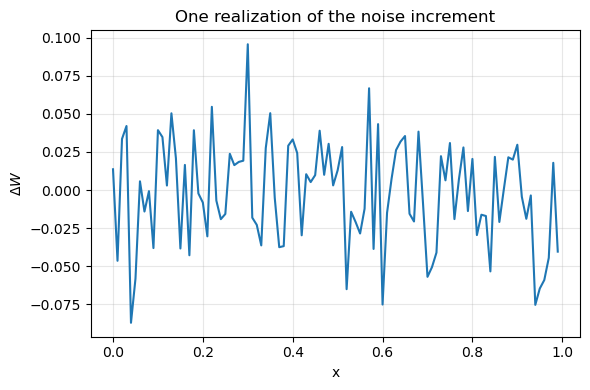

In [5]:
rng = np.random.default_rng(42)

dW = sigma * np.sqrt(dt / h) * rng.normal(size=N)

plt.figure(figsize=(6, 4))
plt.plot(x, dW)

plt.xlabel("x")
plt.ylabel(r"$\Delta W$")
plt.title("One realization of the noise increment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical Method

### Euler--Maruyama Discretization

Using the centered finite-difference approximation for the Laplacian, the Euler--Maruyama update is

$$
u_i^{n+1}
=
u_i^n
+
\kappa\Delta t\,\Delta_h u_i^n
+
u_i^n\Delta W_i^n,
$$

where

$$
\Delta_h u_i^n
=
\frac{
u_{i+1}^n-2u_i^n+u_{i-1}^n
}{h^2}.
$$

In the implementation, the noise-strength parameter $\sigma$ is already included in the generated increment $\Delta W_i^n$.

### One Euler--Maruyama Step

Since the initial condition is spatially constant,

$$
\Delta_h u_0=0.
$$

The diffusion contribution therefore vanishes at the initial time, and the first Euler--Maruyama update is determined entirely by the stochastic term. The following figure compares the initial condition with the solution after one time step.

In [6]:
# One Euler--Maruyama update
diffusion = kappa * dt * laplacian(u0, h)
noise = u0 * dW

u_new = u0 + diffusion + noise

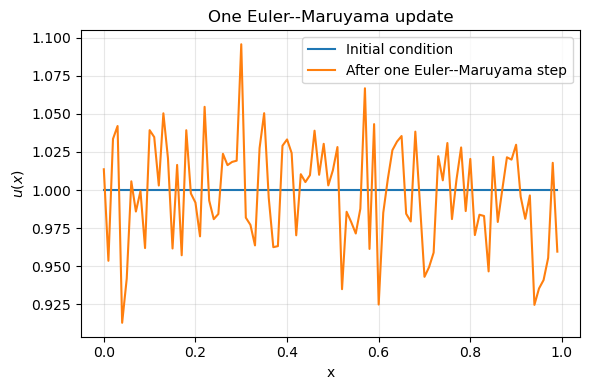

In [7]:
plt.figure(figsize=(6, 4))

plt.plot(x, u0, label="Initial condition")
plt.plot(x, u_new, label="After one Euler--Maruyama step")

plt.xlabel("x")
plt.ylabel(r"$u(x)$")
plt.title("One Euler--Maruyama update")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Numerical Experiments

### Noise Strengths

We now consider several values of $\sigma$ in order to examine how the strength of the multiplicative noise affects the solution.

For each value of $\sigma$, we use the same underlying standardized Gaussian samples. This isolates the effect of changing the noise strength from variation caused by different random realizations.

In [8]:
sigmas = [0.5, 1.0, 2.0, 3.0]

### A Reusable Numerical Solver

The following function implements the Euler--Maruyama scheme over multiple time steps. It records selected snapshots of the solution together with its spatial standard deviation and localization ratio.

In [9]:
def solve_stochastic_heat_equation(u0, h, dt, num_steps, kappa=0.5, sigma=1.0, record_every=100, rng=None):
    """
    Solve the one-dimensional stochastic heat equation with multiplicative space-time white noise using
    the Euler--Maruyama method.
    """
    if rng is None:
        rng = np.random.default_rng()

    u = u0.copy()

    snapshots = [u.copy()]
    times = [0.0]
    stds = [np.std(u)]
    localization = [np.max(u) / np.sum(u)]

    for n in range(num_steps):
        dW = sigma * np.sqrt(dt / h) * rng.normal(size=u.size)

        diffusion = kappa * dt * laplacian(u, h)
        noise = u * dW

        u += diffusion + noise

        if (n + 1) % record_every == 0:
            snapshots.append(u.copy())
            times.append((n + 1) * dt)
            stds.append(np.std(u))
            localization.append(np.max(u) / np.sum(u))

    return {
        "solution": u,
        "snapshots": snapshots,
        "times": times,
        "stds": stds,
        "localization": localization,
    }

### Matched Simulations

We apply the solver to each selected noise strength. Resetting the random number generator before each simulation ensures that the same standardized noise sequence is used in every case.

In [10]:
results = {}

for sigma_value in sigmas:
    rng = np.random.default_rng(42)

    results[sigma_value] = solve_stochastic_heat_equation(
        u0,
        h,
        dt,
        M,
        kappa=kappa,
        sigma=sigma_value,
        record_every=record_every,
        rng=rng,
    )

### Evolution of a Sample Path

We first examine the evolution of one representative sample path using the baseline value $\sigma=1$.

Starting from a spatially constant profile, the multiplicative forcing generates random spatial fluctuations, while diffusion acts continuously to smooth them.

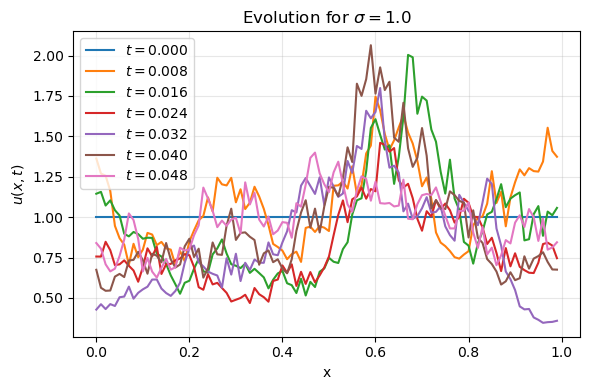

In [11]:
sigma_selected = sigma
selected_result = results[sigma_selected]

plt.figure(figsize=(6, 4))

for u_snapshot, t in zip(
    selected_result["snapshots"],
    selected_result["times"],
):
    plt.plot(x, u_snapshot, label=f"$t={t:.3f}$")

plt.xlabel("x")
plt.ylabel(r"$u(x,t)$")
plt.title(rf"Evolution for $\sigma={sigma_selected}$")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Spatial Variability

As a simple measure of spatial irregularity, we compute the standard deviation of the numerical solution at each recorded time. Larger values indicate greater variation across the spatial domain. Comparing this quantity for several values of $\sigma$ provides a direct measure of how the noise strength affects spatial irregularity.

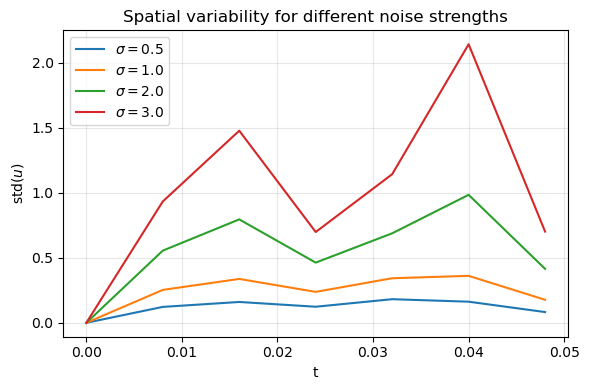

In [12]:
plt.figure(figsize=(6, 4))

for sigma_value in sigmas:
    result = results[sigma_value]

    plt.plot(
        result["times"],
        result["stds"],
        label=rf"$\sigma={sigma_value}$",
    )

plt.xlabel("t")
plt.ylabel(r"$\operatorname{std}(u)$")
plt.title("Spatial variability for different noise strengths")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(
    "figures/noise_strength_comparison.png",
    dpi=200,
    bbox_inches="tight",
)

plt.show()

### Localization

We also compute the localization ratio

$$
\frac{\max_i u_i}{\sum_i u_i},
$$

which measures how concentrated the solution becomes over the spatial grid. Larger values indicate that a greater proportion of the total mass is concentrated near a small number of grid points.

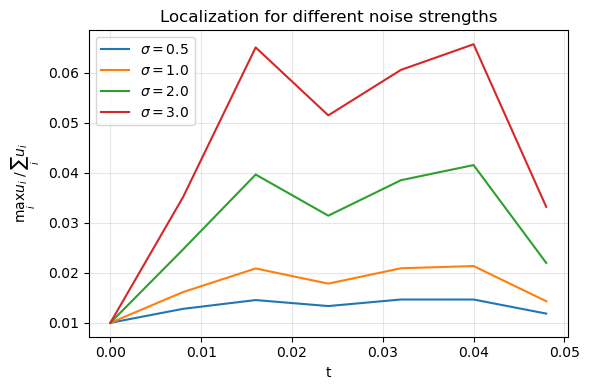

In [13]:
plt.figure(figsize=(6, 4))

for sigma_value in sigmas:
    result = results[sigma_value]

    plt.plot(
        result["times"],
        result["localization"],
        label=rf"$\sigma={sigma_value}$",
    )

plt.xlabel("t")
plt.ylabel(r"$\max_i u_i \,/\, \sum_i u_i$")
plt.title("Localization for different noise strengths")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Summary

In this notebook, we introduced the one-dimensional stochastic heat equation with multiplicative space-time white noise and implemented an Euler--Maruyama solver.

Beginning from a spatially constant initial condition, we examined one stochastic increment, one numerical update, and the evolution of a complete sample path. We then compared several noise strengths using matched Gaussian samples. The numerical experiments show that stronger noise produces greater spatial variability and more pronounced localization along the simulated paths.

In the next notebook, we will move from individual sample paths to ensemble statistics by using Monte Carlo simulation to generate many independent realizations of the stochastic heat equation and investigate how quantities such as the first and second moments depend on the noise strength.